# Step 11 — Owner Submission Gate and Finalization Handoff

## tl;dr

Step 10 completed the scientific related-work package. Submission finalization is now blocked only by owner-controlled facts: venue selection, authorship, institutional applicability/ethics wording, dataset terms, contributions, conflicts, funding, and availability statements.

This notebook provides one editable `OWNER_INPUTS` dictionary, validates it without inventing facts, and produces a machine-readable gate plus a venue-finalization handoff. An incomplete dictionary is an expected state: the notebook completes successfully with `OWNER_INPUT_REQUIRED` rather than raising an assertion.

### Immutable boundary

- Read only sealed Part 2 manuscript and gate artifacts.
- Never access dataset sources, test images, masks, probabilities, models, loaders, or checkpoints.
- Never rerun inference or change the frozen scientific result.
- Never infer owner, institutional, licensing, ethics, conflict, funding, or publication-budget facts.
- Write every generated artifact only to this phase's `outputs/` directory.


## Context & Methods

### Key Assumptions

- Step 10 is the current scientific manuscript authority.
- Step 08's venue matrix is decision support, not an owner selection.
- `False`, blank text, `None`, placeholder text, and unverified statements cannot pass a required confirmation gate.
- Even a passed owner gate does not mean submission-ready: the selected venue's live instructions must be refreshed before formatting and submission.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re
import pandas as pd
import matplotlib.pyplot as plt

STEP_DIR = Path.cwd().resolve()
if STEP_DIR.name != "step_11_owner_submission_gate_and_finalization_handoff":
    candidate = STEP_DIR / "step_11_owner_submission_gate_and_finalization_handoff"
    if candidate.is_dir(): STEP_DIR = candidate.resolve()
PART2 = STEP_DIR.parent
S8 = PART2 / "step_08_venue_selection_and_owner_intake" / "outputs"
S10 = PART2 / "step_10_related_work_evidence_and_comparability" / "outputs"
OUT = STEP_DIR / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

MANIFEST_SHA256 = "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
TEST_RUN_ID = "871d289b-bf6b-4346-978f-2df02ade26ab"
CREATED_UTC = datetime.now(timezone.utc).isoformat()

# OWNER EDIT ZONE — replace every None/blank value with verified owner facts.
# Do not enter credentials, passwords, private keys, or submission-system tokens.
OWNER_INPUTS = {
    "selected_venue": "",
    "open_access_required": None,                 # True or False
    "maximum_publication_budget_usd": None,       # number >= 0
    "corresponding_author_name": "",
    "corresponding_author_email": "",
    "authors_and_affiliations": "",
    "ethics_or_applicability_statement": "",
    "dataset_terms_and_availability_statement": "",
    "author_contributions_statement": "",
    "conflicts_of_interest_statement": "",
    "funding_statement": "",
    "code_availability_statement": "",
    "data_availability_statement": "",
    "owner_certifies_accuracy": None,             # must be True
}

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""): h.update(block)
    return h.hexdigest()
def load_json(path): return json.loads(Path(path).read_text(encoding="utf-8"))
def save_json(obj, name):
    path = OUT / name; path.write_text(json.dumps(obj, indent=2, sort_keys=True), encoding="utf-8"); return path
def save_csv(df, name):
    path = OUT / name; df.to_csv(path, index=False); return path

print("Owner fields supplied:", sum(v not in (None, "") for v in OWNER_INPUTS.values()), "/", len(OWNER_INPUTS))
print("No dataset or test-source path is defined.")

Owner fields supplied: 0 / 14
No dataset or test-source path is defined.


## Data

### 1. Verify sealed Step 08 and Step 10 inputs


In [2]:
gate8 = load_json(S8 / "gate_result.json")
gate10 = load_json(S10 / "gate_result.json")
sig10 = load_json(S10 / "step_10_signature.json")
venues = pd.read_csv(S8 / "venue_source_and_candidate_matrix.csv")
shortlist = pd.read_csv(S8 / "venue_shortlist.csv")
manuscript_path = S10 / "PAPER_DRAFT_WITH_EXPANDED_RELATED_WORK.md"

signed_rows = []
for rel, expected in sig10["signed_artifacts"].items():
    path = PART2 / rel
    actual = sha256(path) if path.is_file() else None
    signed_rows.append({"artifact": rel, "expected_sha256": expected, "actual_sha256": actual,
                        "passed": actual == expected})
signed10 = pd.DataFrame(signed_rows)

checks = [
 ("step08_decision_support_complete", gate8.get("result_level") == "VENUE_DECISION_SUPPORT_COMPLETE", gate8.get("result_level")),
 ("step08_owner_gate_unresolved", gate8.get("submission_ready") is False, gate8.get("submission_ready")),
 ("step10_related_work_complete", gate10.get("result_level") == "RELATED_WORK_EVIDENCE_COMPLETE", gate10.get("result_level")),
 ("step10_all_targets_pass", gate10.get("all_mandatory_targets_passed") is True, gate10.get("all_mandatory_targets_passed")),
 ("formal_failure_preserved", gate10.get("formal_model_acceptance_passed") is False, gate10.get("formal_model_acceptance_passed")),
 ("manifest_hash", gate10.get("manifest_sha256") == MANIFEST_SHA256, gate10.get("manifest_sha256")),
 ("test_run_id", gate10.get("source_test_run_id") == TEST_RUN_ID, gate10.get("source_test_run_id")),
 ("test_sources_not_reopened", gate10.get("test_source_files_reopened") is False, gate10.get("test_source_files_reopened")),
 ("test_inference_not_rerun", gate10.get("test_inference_rerun") is False, gate10.get("test_inference_rerun")),
 ("step10_signature_valid", bool(len(signed10)) and bool(signed10.passed.all()), f"{int(signed10.passed.sum())}/{len(signed10)}"),
 ("expanded_manuscript_exists", manuscript_path.is_file(), str(manuscript_path)),
 ("venue_matrix_nonempty", len(venues) >= 3, len(venues)),
]
verification = pd.DataFrame(checks, columns=["check", "passed", "observed"])
save_csv(verification, "input_verification.csv")
assert verification.passed.all(), verification.loc[~verification.passed].to_dict("records")
print(f"PASS: {verification.passed.sum()}/{len(verification)} sealed-input checks")

PASS: 12/12 sealed-input checks


## Results

### 2. Validate owner inputs without inventing missing facts


In [3]:
placeholder_tokens = ["owner required", "tbd", "todo", "unknown", "placeholder", "insert ", "your "]
valid_venues = set(venues["venue"].astype(str))

def text_complete(value, minimum=3):
    if not isinstance(value, str) or len(value.strip()) < minimum: return False
    low = value.strip().lower()
    return not any(token in low for token in placeholder_tokens)

rows = []
for field, value in OWNER_INPUTS.items():
    if field == "selected_venue":
        passed = isinstance(value, str) and value.strip() in valid_venues
        rule = "must exactly match a venue in the verified Step 08 matrix"
    elif field == "open_access_required":
        passed = isinstance(value, bool)
        rule = "must be explicitly True or False"
    elif field == "maximum_publication_budget_usd":
        passed = isinstance(value, (int, float)) and not isinstance(value, bool) and value >= 0
        rule = "must be a non-negative number"
    elif field == "corresponding_author_email":
        passed = isinstance(value, str) and bool(re.fullmatch(r"[^\s@]+@[^\s@]+\.[^\s@]+", value.strip()))
        rule = "must be a syntactically valid email address"
    elif field == "owner_certifies_accuracy":
        passed = value is True
        rule = "must be explicitly True after owner review"
    elif field.endswith("_statement") or field == "authors_and_affiliations":
        passed = text_complete(value, minimum=10)
        rule = "must contain a verified non-placeholder statement of at least 10 characters"
    else:
        passed = text_complete(value, minimum=3)
        rule = "must contain verified non-placeholder text"
    rows.append({"field": field, "value": value, "validation_rule": rule, "complete": bool(passed)})

status = pd.DataFrame(rows)
save_csv(status, "owner_input_status.csv")
template = status[["field", "validation_rule"]].copy()
template["owner_value"] = ""
save_csv(template, "owner_input_template.csv")

blockers = status.loc[~status.complete, ["field", "validation_rule"]].rename(
    columns={"field":"blocker", "validation_rule":"required_action"})
if not blockers.empty:
    blockers.insert(0, "category", "owner input")
save_csv(blockers, "submission_blockers.csv")

owner_gate_passed = bool(status.complete.all())
selected_venue = OWNER_INPUTS["selected_venue"].strip() if status.loc[status.field.eq("selected_venue"), "complete"].iloc[0] else None
print(f"Owner gate: {int(status.complete.sum())}/{len(status)} complete; passed={owner_gate_passed}")

Owner gate: 0/14 complete; passed=False


### 3. Create the owner action pack and conditional finalization handoff


In [4]:
actions = [
 "# Manual Owner Actions", "",
 "Complete the `OWNER_INPUTS` dictionary in code Cell 1, then use **Restart Kernel and Run All**.",
 "Do not enter passwords, API keys, journal credentials, or payment-card details.", "",
 f"Current completion: **{int(status.complete.sum())}/{len(status)} fields**.", "",
]
for r in status.loc[~status.complete].itertuples(index=False):
    actions.append(f"- **{r.field}** — {r.validation_rule}")
actions += ["", "Passing this gate authorizes preparation work only. It does not authorize journal submission or payment."]
(OUT / "MANUAL_OWNER_ACTIONS.md").write_text("\n".join(actions), encoding="utf-8")

if owner_gate_passed:
    venue_row = venues.loc[venues.venue.eq(selected_venue)].iloc[0]
    declarations = [
      "# Owner-Confirmed Submission Statements", "",
      f"- Selected venue: {selected_venue}",
      f"- Corresponding author: {OWNER_INPUTS['corresponding_author_name']} ({OWNER_INPUTS['corresponding_author_email']})",
      f"- Authors and affiliations: {OWNER_INPUTS['authors_and_affiliations']}",
      f"- Ethics/applicability: {OWNER_INPUTS['ethics_or_applicability_statement']}",
      f"- Dataset terms and availability: {OWNER_INPUTS['dataset_terms_and_availability_statement']}",
      f"- Author contributions: {OWNER_INPUTS['author_contributions_statement']}",
      f"- Conflicts of interest: {OWNER_INPUTS['conflicts_of_interest_statement']}",
      f"- Funding: {OWNER_INPUTS['funding_statement']}",
      f"- Code availability: {OWNER_INPUTS['code_availability_statement']}",
      f"- Data availability: {OWNER_INPUTS['data_availability_statement']}",
    ]
    finalization = [
      "# Selected-Venue Finalization Handoff", "",
      f"Selected venue: **{selected_venue}**", "",
      f"Step 08 official page: {venue_row.official_url}",
      f"Step 08 requirements snapshot: {venue_row.relevant_requirements}", "",
      "## Required next actions", "",
      "1. Refresh the selected venue's official author instructions, article type, declarations, word limits, figure/table limits, reference style, fees and waiver policy.",
      "2. Apply the owner-confirmed statements to the expanded Step 10 manuscript without changing the sealed scientific results.",
      "3. Produce the title page, cover letter, reporting checklist and venue-formatted manuscript.",
      "4. Run a final numerical/citation/hash reconciliation before any external submission.",
      "5. Keep submission and any payment as an explicit owner action outside this notebook.",
    ]
else:
    declarations = ["# Owner-Confirmed Submission Statements", "", "Not generated: owner input gate is incomplete."]
    finalization = [
      "# Selected-Venue Finalization Handoff", "",
      "Status: **BLOCKED — OWNER INPUT REQUIRED**", "",
      f"Complete the {len(blockers)} unresolved fields listed in `MANUAL_OWNER_ACTIONS.md`.",
      "No venue-specific manuscript, cover letter, checklist, submission or payment is authorized.",
    ]

(OUT / "OWNER_CONFIRMED_DECLARATIONS.md").write_text("\n".join(declarations), encoding="utf-8")
(OUT / "SELECTED_VENUE_FINALIZATION_HANDOFF.md").write_text("\n".join(finalization), encoding="utf-8")
print("Finalization handoff status:", "READY_FOR_LIVE_REQUIREMENTS_REFRESH" if owner_gate_passed else "OWNER_INPUT_REQUIRED")

Finalization handoff status: OWNER_INPUT_REQUIRED


## Takeaways

### 4. Save the decision gate, provenance, signature, and bounded visualization


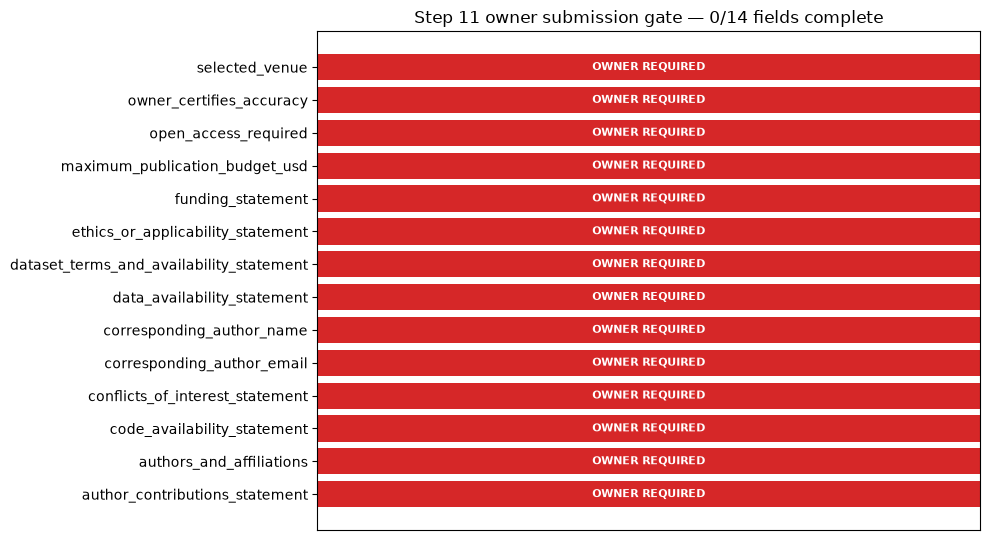

PASS: phase integrity 7/7; result=OWNER_INPUT_REQUIRED
Decision: OWNER_COMPLETE_REQUIRED_FIELDS
Next step: edit_owner_inputs_and_rerun_step_11


In [5]:
complete_count = int(status.complete.sum())
result_level = "OWNER_INPUT_GATE_PASS" if owner_gate_passed else "OWNER_INPUT_REQUIRED"
decision = "REFRESH_SELECTED_VENUE_REQUIREMENTS_AND_BUILD_FINAL_PACKAGE" if owner_gate_passed else "OWNER_COMPLETE_REQUIRED_FIELDS"
next_step = "selected_venue_live_requirements_refresh" if owner_gate_passed else "edit_owner_inputs_and_rerun_step_11"

expected = pd.DataFrame([
 ("sealed input checks", len(verification), int(verification.passed.sum()), bool(verification.passed.all())),
 ("owner input fields represented", len(OWNER_INPUTS), len(status), len(status)==len(OWNER_INPUTS)),
 ("owner blockers saved", True, (OUT/"submission_blockers.csv").is_file(), (OUT/"submission_blockers.csv").is_file()),
 ("manual action pack saved", True, (OUT/"MANUAL_OWNER_ACTIONS.md").is_file(), (OUT/"MANUAL_OWNER_ACTIONS.md").is_file()),
 ("formal model failure preserved", False, False, True),
 ("test inference reruns", 0, 0, True),
 ("test source files reopened", 0, 0, True),
], columns=["requirement","expected","actual","passed"])
save_csv(expected, "expected_vs_actual.csv")

configuration = {
 "phase":"step_11_owner_submission_gate_and_finalization_handoff","created_utc":CREATED_UTC,
 "mode":"artifact_only_owner_gate","owner_inputs":OWNER_INPUTS,
 "manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "submission_action_authorized":False,"payment_action_authorized":False,
 "test_access_allowed":False,
}
save_json(configuration, "configuration.json")

gate = {
 "status":result_level.lower(),"result_level":result_level,
 "all_phase_integrity_targets_passed":bool(expected.passed.all()),
 "owner_gate_passed":owner_gate_passed,"owner_fields_complete":complete_count,
 "owner_fields_total":len(status),"unresolved_owner_fields":int((~status.complete).sum()),
 "venue_selected":selected_venue,"decision":decision,"next_step":next_step,
 "submission_ready":False,"venue_finalization_ready":owner_gate_passed,
 "submission_action_authorized":False,"payment_action_authorized":False,
 "formal_model_acceptance_passed":False,"formal_model_acceptance_failure":"minimum_positive_patient_dice",
 "manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False,
 "targets":{r.requirement:bool(r.passed) for r in expected.itertuples(index=False)},
}
assert gate["all_phase_integrity_targets_passed"]
save_json(gate, "gate_result.json")

provenance = {
 "created_utc":CREATED_UTC,"phase":configuration["phase"],"result_level":result_level,
 "step08_gate_sha256":sha256(S8/"gate_result.json"),"step10_gate_sha256":sha256(S10/"gate_result.json"),
 "step10_signature_sha256":sha256(S10/"step_10_signature.json"),
 "expanded_manuscript_sha256":sha256(manuscript_path),
 "manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False,
}
save_json(provenance, "provenance.json")

fig, ax = plt.subplots(figsize=(10, 5.5))
ordered = status.sort_values(["complete","field"], ascending=[True,True])
colors = ["#2ca02c" if x else "#d62728" for x in ordered.complete]
ax.barh(ordered.field, [1]*len(ordered), color=colors)
ax.set_xlim(0,1); ax.set_xticks([]); ax.set_xlabel("")
ax.set_title(f"Step 11 owner submission gate — {complete_count}/{len(status)} fields complete")
for i, ok in enumerate(ordered.complete): ax.text(.5, i, "COMPLETE" if ok else "OWNER REQUIRED", ha="center", va="center", color="white", fontweight="bold", fontsize=8)
fig.tight_layout(); fig.savefig(OUT/"owner_submission_gate_dashboard.png", dpi=180, bbox_inches="tight"); plt.show()

signed_names = ["input_verification.csv","owner_input_template.csv","owner_input_status.csv","submission_blockers.csv",
 "MANUAL_OWNER_ACTIONS.md","OWNER_CONFIRMED_DECLARATIONS.md","SELECTED_VENUE_FINALIZATION_HANDOFF.md",
 "expected_vs_actual.csv","configuration.json","gate_result.json","provenance.json","owner_submission_gate_dashboard.png"]
signed_artifacts = {f"step_11_owner_submission_gate_and_finalization_handoff/outputs/{n}":sha256(OUT/n) for n in signed_names}
combined = hashlib.sha256("".join(f"{k}:{v}\n" for k,v in sorted(signed_artifacts.items())).encode()).hexdigest()
signature = {"algorithm":"SHA-256","created_utc":CREATED_UTC,"combined_sha256":combined,
 "signed_artifacts":signed_artifacts,"result_level":result_level,"owner_gate_passed":owner_gate_passed,
 "formal_model_acceptance_passed":False,"submission_ready":False,
 "submission_action_authorized":False,"payment_action_authorized":False,
 "test_source_files_reopened":False,"test_inference_rerun":False}
save_json(signature, "step_11_signature.json")

print(f"PASS: phase integrity {expected.passed.sum()}/{len(expected)}; result={result_level}")
print("Decision:", decision)
print("Next step:", next_step)

## Takeaways

- `OWNER_INPUT_REQUIRED` is the correct successful execution state while owner facts are absent; it is not a notebook failure.
- Edit only `OWNER_INPUTS` in code Cell 1 and then use **Restart Kernel and Run All**.
- `OWNER_INPUT_GATE_PASS` permits a new live venue-instructions refresh and formatting phase. It still does not authorize journal submission or payment.
- The sealed scientific result remains unchanged: formal model acceptance failed, and no further test access or model tuning is permitted.
